# CartPole with PyAOgmaNeo - Manual Implementation

VERSION NOTE: Master (commit: 379be3b)

## Introduction

This example demonstrates training a **PyAOgmaNeo** agent to solve the classic CartPole control problem. This implementation provides complete control over the architecture and shows exactly how SPH (Sparse Predictive Hierarchies) works.

**The CartPole Problem:** Keep a pole balanced on a moving cart by pushing left or right. This requires:
- Understanding current state (position, velocity, angle, angular velocity)
- Predicting future states based on actions
- Learning from mistakes to improve policy

PyAOgmaNeo uses **Sparse Predictive Hierarchies**, which:
- Learn online, updating every timestep
- Predict what will happen next, not just reward
- Use extremely sparse representations (only ~1% of neurons active)
- Run efficiently on CPUs without GPUs

> **New to neuromorphic computing?** Check out the [History of Neuromorphic Computing](../../overview/history_of_neuromorphic_computing.md) to understand the brain-inspired principles behind SPH.

## What This Example Covers

This notebook demonstrates:

1. Converting continuous observations to CSDR (sparse neural codes)
2. Manual hierarchy architecture setup
3. The "squash and bin" encoding technique
4. Online predictive reinforcement learning
5. Reward shaping strategies
6. Training visualization and analysis

## Structure

1. **Dependencies** - Required packages
2. **Setup and Imports** - Library initialization
3. **Configuration** - Hyperparameters and architecture
4. **Environment** - CartPole-v1 from Gymnasium
5. **CSDR Encoding** - The "squash and bin" method
6. **Agent Architecture** - Manual hierarchy construction
7. **Training Loop** - Online learning implementation
8. **Visualization** - Performance plots
9. **Testing** - Evaluating the trained agent
10. **Analysis** - Understanding what the agent learned


## 0. Dependencies

This example requires the following Python libraries:

### Required Libraries

| Library | Purpose | Description |
|---------|---------|-------------|
| **PyAOgmaNeo** | The SPH neural network library | Core agent implementation |
| **Gymnasium** | Standard RL environment interface | Provides the CartPole simulation |
| **NumPy** | Numerical computing | Array operations and encoding |
| **Matplotlib** | Visualization | Training performance plots |

### Installation Notes

- If you already have these installed, skip this cell
- CartPole is included with Gymnasium by default

> **More details:** See the full [Installation Guide](../../getting_started/installation.md) for troubleshooting and alternative installation methods.


In [1]:
# Install dependencies into this environment.
# Run this once.
# %pip install gymnasium numpy matplotlib pyaogmaneo


## 1. Setup and Imports

This section imports required libraries and sets up the workspace.

### Import Overview

```python
import pyaogmaneo as neo
```

This is our main library. It provides:
- `Hierarchy` - The main predictive learning network
- `LayerDesc` - Layer configuration objects
- `IODesc` - Input/output stream descriptors
- Helper functions for managing neural state

```python
import gymnasium as gym
```

**Gymnasium** is the standard way to interact with reinforcement learning environments. It gives us:
- `reset()` - Start a new episode
- `step(action)` - Take an action, get back observation/reward/termination
- Standardized interfaces across hundreds of environments

**Why Gymnasium?** It's the maintained successor to OpenAI Gym and is now the community standard.

```python
import numpy as np
```

We use NumPy for:
- The sigmoid function (continuous → bounded mapping)
- Array operations for encoding observations
- Statistical analysis of training results


In [12]:
import pyaogmaneo as neo
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Configuration

This section defines all hyperparameters for the agent architecture and training schedule.

### CSDR Encoding Parameters

```python
input_resolution = 32
encoding_scale = 3.0
```

**input_resolution = 32:** Each continuous observation value is discretized into 32 bins.
- Higher values (64, 128): More fine-grained encoding, larger memory requirements
- Lower values (16, 8): Coarser encoding, faster but less precise
- 32 is a good default balance

**encoding_scale = 3.0:** How much to multiply observations before applying sigmoid.
- Higher values: More sensitive to small changes (might be noisy)
- Lower values: Less sensitive, smoother but might miss important details
- 3.0 works well for CartPole's observation ranges

### SPH Architecture Parameters

```python
input_size = (2, 2, input_resolution)   # 4 observations in a 2×2 spatial grid
hidden_size = (5, 5, 32)                # Hierarchy layer size
num_layers = 2                           # Number of hierarchy layers
```

The architecture processes information hierarchically:

**1. Input Layer (2×2×32):**
- Arranges 4 observations in a 2×2 spatial grid
- Each position represents one observation (position, velocity, angle, angular velocity)
- 32 possible discrete values per observation

**2. Hidden Layers (5×5×32, two layers):**
- Each layer has a 5×5 spatial structure with 32 features per position
- Layer 0: Learns immediate state transitions
- Layer 1: Learns longer-term temporal patterns
- Total representational capacity: 32^(25+25) possible states

Two layers is sufficient for CartPole because the dynamics are relatively simple compared to Atari games. This provides enough temporal depth without unnecessary computation.

> **Deep dive:** Learn about [CSDR (Columnar Sparse Distributed Representations)](../../technical_guide/core_concepts.md#csdr-the-common-language) to understand this architecture's theoretical foundation.

### Training Schedule

```python
max_episodes = 1000
max_timesteps = 500
reward_scale = 1.0
```

**max_episodes = 1000:** Train for 1000 episodes (games).
- CartPole typically learns in 500-800 episodes
- 1000 ensures convergence with some margin

**max_timesteps = 500:** Maximum steps per episode.
- CartPole-v1 automatically terminates at 500 steps
- This matches the environment's natural limit

**reward_scale = 1.0:** Multiplier for reward values.
- We use custom reward shaping (-10 on failure, 0 otherwise)
- Scale of 1.0 means we use rewards as-is
- Could increase for stronger learning signals

### CPU Parallelism

```python
neo.set_num_threads(4)
```

PyAOgmaNeo can use multiple CPU cores for parallel computation. Set this to the number of cores you want to use.

> **Learn more:** See the [Parameter Tuning Guide](../../technical_guide/parameter_tuning.md) for systematic hyperparameter optimization advice.

In [ ]:
# 2. Configuration

# CSDR encoding parameters
input_resolution = 32      # Number of discrete bins per observation
encoding_scale = 3.0       # Sensitivity multiplier for sigmoid

# SPH architecture
input_size = (2, 2, input_resolution)   # 4 observations in 2×2 grid
hidden_size = (5, 5, 32)                # Hidden layer size
num_layers = 1                           # Number of hierarchy layers

# Training schedule
max_episodes = 1000        # Number of training episodes
max_timesteps = 500        # Max steps per episode
reward_scale = 1.0         # Reward multiplier

# Parallelism for PyAOgmaNeo
neo.set_num_threads(8)

print(f"Configured for {max_episodes} training episodes.")
print(f"Input: {input_size}, Hidden: {hidden_size}, Layers: {num_layers}")

Configured for 1000 training episodes.
Input: (2, 2, 32), Hidden: (5, 5, 32), Layers: 1


## 3. CartPole Environment

This section creates and configures the Gymnasium CartPole environment.

### What is CartPole?

CartPole is a classic control problem:
- A pole is attached to a cart on a frictionless track
- The pole starts upright
- You can push the cart left or right
- Goal: Keep the pole from falling over

This is analogous to balancing a broomstick on your hand by moving your hand left/right to keep it upright.

### Observation Space Details

CartPole provides 4 continuous values:

| Index | Observation | Min | Max | Description |
|-------|-------------|-----|-----|-------------|
| 0 | Cart Position | -4.8 | 4.8 | Position along track |
| 1 | Cart Velocity | -∞ | +∞ | How fast cart is moving |
| 2 | Pole Angle | -0.418 | 0.418 | Angle from vertical (radians) |
| 3 | Pole Angular Velocity | -∞ | +∞ | How fast pole is rotating |

**Challenge:** These are continuous, unbounded values. PyAOgmaNeo needs discrete sparse representations (CSDR), which requires encoding.

### Action Space

CartPole has 2 discrete actions:
- `0`: Push cart to the left
- `1`: Push cart to the right

### Episode Termination

An episode ends when:
1. **Pole angle exceeds ±12 degrees** (0.2095 radians) → `terminated = True`
2. **Cart position exceeds ±2.4** → `terminated = True`
3. **Episode reaches 500 timesteps** → `truncated = True` (maximum episode length)

### Success Criteria

CartPole-v1 is considered "solved" when:
- Average reward over 100 consecutive episodes ≥ 475
- This means consistently balancing for almost the full 500 steps

> **Learn more:** See [Gymnasium's CartPole documentation](https://gymnasium.farama.org/environments/classic_control/cart_pole/) for mathematical details of the physics simulation.

In [25]:
# 3. Create the CartPole environment

env = gym.make('CartPole-v1')

num_obs = env.observation_space.shape[0]  # Should be 4
num_actions = env.action_space.n           # Should be 2

print(f"Environment: CartPole-v1")
print(f"Observation space: {num_obs} continuous values")
print(f"  - Cart position, velocity")
print(f"  - Pole angle, angular velocity")
print(f"Action space: {num_actions} discrete actions (left/right)")
print(f"Goal: Balance pole for 500 timesteps")

Environment: CartPole-v1
Observation space: 4 continuous values
  - Cart position, velocity
  - Pole angle, angular velocity
Action space: 2 discrete actions (left/right)
Goal: Balance pole for 500 timesteps


## 4. CSDR Encoding - The "Squash and Bin" Method

This technique enables PyAOgmaNeo to work with continuous observations.

### The Problem

The challenge is converting continuous observations to discrete representations:
- **Input:** 4 continuous values (e.g., cart position = 1.837, velocity = -0.523, ...)
- **Required output:** Discrete sparse representations that PyAOgmaNeo can process
- **Complication:** Observations can be unbounded (velocities can be very large)

### The Solution: Squash and Bin

**Step 1: Squash with Sigmoid**

```python
def sigmoid(x):
    return np.tanh(x * 0.5) * 0.5 + 0.5
```

This function maps any input to the range [0, 1]:
- Very negative values (e.g., -100) → ~0.0
- Zero → 0.5
- Very positive values (e.g., +100) → ~1.0

This sigmoid function has several useful properties:
- `tanh(x * 0.5)` creates a smooth S-curve that handles unbounded inputs
- The `* 0.5 + 0.5` shifts and scales to [0, 1] range
- It preserves useful gradations while handling extreme values

**Step 2: Scale and Discretize**

```python
csdr = (sigmoid(obs * encoding_scale) * (input_resolution - 1) + 0.5).astype(np.int32)
```

This converts [0, 1] → [0, 31] discrete integers:
1. Scale observations by `encoding_scale` (3.0) before sigmoid
2. `* (input_resolution - 1)` scales to [0, 31]
3. `+ 0.5` adds rounding offset
4. `.astype(np.int32)` converts to integer

### Key Properties

- **Preserves ordering:** Larger values → larger bins
- **Handles extremes:** Very large values don't break the system
- **Smooth transitions:** Similar values map to similar bins
- **Fixed range:** Always 0-31, regardless of input magnitude

### CSDR Format Requirements

In PyAOgmaNeo, CSDR means:
- Each column (spatial position) can have exactly one active cell
- That cell's index represents the encoded value
- For CartPole: 4 columns (2×2 grid), each with values 0-31

This is what the encoding produces.

> **Deep dive:** See [CSDR: The Common Language](../../technical_guide/core_concepts.md#csdr-the-common-language) for the theoretical foundation.

In [26]:
# 4. Define the "squash and bin" encoding function

def sigmoid(x):
    """Squash any input to [0, 1] range using smooth S-curve."""
    return np.tanh(x * 0.5) * 0.5 + 0.5

def encode_observation(obs):
    """Convert continuous observations to discrete CSDR format.
    
    Args:
        obs: Array of 4 continuous values
        
    Returns:
        Array of 4 discrete integers (0 to input_resolution-1)
    """
    csdr = (sigmoid(obs * encoding_scale) * (input_resolution - 1) + 0.5).astype(np.int32)
    return csdr

# Test the encoding with a sample observation
test_obs = np.array([0.5, -1.2, 0.1, 0.8])
test_encoded = encode_observation(test_obs)

print("Encoding demonstration:")
print(f"Raw observations:     {test_obs}")
print(f"After sigmoid:        {sigmoid(test_obs * encoding_scale)}")
print(f"Encoded to bins:      {test_encoded}")
print(f"\nEach value is now a discrete bin (0-{input_resolution-1})")

Encoding demonstration:
Raw observations:     [ 0.5 -1.2  0.1  0.8]
After sigmoid:        [0.81757448 0.02659699 0.57444252 0.9168273 ]
Encoded to bins:      [25  1 18 28]

Each value is now a discrete bin (0-31)


## 5. Hierarchy Construction

This section builds the SPH agent from scratch using the Hierarchy API.

### Input/Output Descriptors (IODesc)

**IODesc 0: Observation Input**
```python
neo.IODesc((2, 2, input_resolution), neo.none)
```

- **Size:** (2, 2, 32) - Four observations in a 2×2 spatial grid
- **Type:** `neo.none` - Pure observation input, not predicted directly
- **Layout:**
  ```
  (0,0): Cart Position    | (0,1): Cart Velocity
  (1,0): Pole Angle       | (1,1): Pole Angular Velocity
  ```

**IODesc 1: Action Output**
```python
neo.IODesc((1, 1, num_actions), neo.action)
```

- **Size:** (1, 1, 2) - Single action choice between left/right
- **Type:** `neo.action` - Reinforcement learning output with automatic exploration

### Layer Descriptors (LayerDesc)

Each hierarchy layer needs configuration:

```python
ld = neo.LayerDesc()
ld.hidden_size = (5, 5, 32)
```

**What each layer does:**
- **Layer 0 (bottom):** Processes immediate observations, learns state transitions
- **Layer 1 (top):** Learns longer temporal patterns, integrates information over time

**Hidden size (5, 5, 32):**
- 5×5 = 25 spatial positions for processing
- 32 possible features per position (column size)
- Creates a rich representational space: 32^25 possible patterns

> **Learn more:** See [Hierarchy API Reference](../../api_reference/hierarchy.md) for all configuration options.

In [27]:
# 5. Build the SPH agent architecture

# Define layer descriptors
lds = []
for i in range(num_layers):
    ld = neo.LayerDesc()
    ld.hidden_size = hidden_size
    lds.append(ld)

# Create hierarchy with two IO streams:
#   - Stream 0: Observations (2×2×32 CSDR)
#   - Stream 1: Actions (1×1×2 discrete)
h = neo.Hierarchy(
    [
        neo.IODesc(input_size, neo.none),                  # Observations
        neo.IODesc((1, 1, num_actions), neo.action),       # Actions
    ],
    lds,
)

print("Hierarchy created successfully!")
print(f"  Input size:  {input_size}")
print(f"  Layer 0 hidden size: {h.get_hidden_size(0)}")
print(f"  Layer 1 hidden size: {h.get_hidden_size(1)}")
print(f"  Action space: {num_actions} discrete actions")
print(f"\nThe agent is ready to learn!")

Hierarchy created successfully!
  Input size:  (2, 2, 32)
  Layer 0 hidden size: (5, 5, 32)


RuntimeError: error: 1 is not a valid layer index!

## 6. Training Loop - Online Predictive Learning

This section implements the main training loop that teaches the agent to balance the pole.

### The Core Learning Cycle

```python
# 1. Encode observations to CSDR
csdr = encode_observation(obs)

# 2. Step hierarchy (learn and predict)
h.step([csdr, h.get_prediction_cis(1)], True, reward)

# 3. Get predicted action
action = h.get_prediction_cis(1)[0]

# 4. Execute in environment
obs, reward, term, trunc, _ = env.step(action)

# 5. Shape reward
if term:
    reward = -10.0
else:
    reward = 0.0
```

### Understanding Each Step

**Step 2: Hierarchy Step**
```python
h.step([csdr, h.get_prediction_cis(1)], True, reward)
```
- **First argument:** Input list containing current observations and previous action
- **Second argument:** `True` enables learning
- **Third argument:** `reward` from previous timestep

Inside the hierarchy step:
1. Compare predicted state with actual state (prediction error)
2. Update internal representations based on error
3. Apply reward to strengthen/weaken action associations
4. Generate new predictions for next timestep

**Step 5: Reward Shaping**
```python
if term:
    reward = -10.0
else:
    reward = 0.0
```

This reward shaping approach has several advantages:
- Agent learns to avoid the bad state (falling)
- More biologically plausible (organisms avoid pain)
- Works well with predictive learning (predicting failure → avoid)

### Fully Online Learning

The model updates at every timestep:
- No replay buffers storing past experiences
- No batch processing
- No separate training/execution phases

> **Learn more:** See [Reinforcement Learning Guide](../../user_guide/reinforcement_learning.md) for the theory behind SPH's online learning.

In [28]:
# 6. Training loop implementation

def train_agent():
    """Train the CartPole agent and return training statistics."""
    
    episode_lengths = []
    episode_rewards = []
    
    print(f"Starting training for {max_episodes} episodes...\n")
    
    reward = 0.0  # Initial reward for first timestep
    
    for episode in range(max_episodes):
        obs, _ = env.reset()
        total_reward = 0.0
        
        for t in range(max_timesteps):
            # 1. Encode observations to CSDR
            csdr = encode_observation(obs)
            
            # 2. Step hierarchy: learn from previous reward, generate predictions
            h.step([csdr, h.get_prediction_cis(1)], True, reward * reward_scale)
            
            # 3. Get predicted action (exploration already applied)
            action = h.get_prediction_cis(1)[0]
            
            # 4. Execute action in environment
            obs, reward, term, trunc, _ = env.step(action)
            
            # 5. Reshape reward: penalize failure, neutral otherwise
            if term:
                reward = -10.0
            else:
                reward = 0.0
            
            total_reward += reward
            
            if term or trunc:
                break
        
        # Record statistics
        episode_lengths.append(t + 1)
        episode_rewards.append(total_reward)
        
        # Print progress every 50 episodes
        if (episode + 1) % 50 == 0:
            avg_length = np.mean(episode_lengths[-50:])
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode + 1:4d}: avg length = {avg_length:6.1f}, avg reward = {avg_reward:6.1f}")
    
    print("\nTraining complete!")
    
    return np.array(episode_lengths), np.array(episode_rewards)

# Run training
episode_lengths, episode_rewards = train_agent()

Starting training for 1000 episodes...

Episode   50: avg length =   22.5, avg reward =  -10.0
Episode  100: avg length =   28.0, avg reward =  -10.0
Episode  150: avg length =   49.6, avg reward =  -10.0
Episode  200: avg length =  115.5, avg reward =   -9.8
Episode  250: avg length =  229.9, avg reward =   -9.4
Episode  300: avg length =  281.2, avg reward =   -9.4
Episode  350: avg length =  298.3, avg reward =   -8.8
Episode  400: avg length =  294.9, avg reward =   -9.2
Episode  450: avg length =  264.7, avg reward =   -9.4
Episode  500: avg length =  271.6, avg reward =   -9.2
Episode  550: avg length =  303.2, avg reward =   -8.0
Episode  600: avg length =  335.2, avg reward =   -7.4
Episode  650: avg length =  329.5, avg reward =   -7.4
Episode  700: avg length =  309.1, avg reward =   -8.2
Episode  750: avg length =  328.1, avg reward =   -7.8
Episode  800: avg length =  381.3, avg reward =   -5.8
Episode  850: avg length =  352.1, avg reward =   -6.8
Episode  900: avg length 

## 7. Visualization - Training Performance

This section visualizes how the agent learned over time.

### Episode Length Plot

This shows how long each episode lasted (how many timesteps before the pole fell).

**Training progression:**
- **Early training:** Short episodes (pole falls quickly)
- **Learning phase:** Gradual increase in episode length
- **Solved:** Consistent 500-step episodes (maximum length)

### Success Criteria

Average over 100 episodes ≥ 475 means the task is "solved".

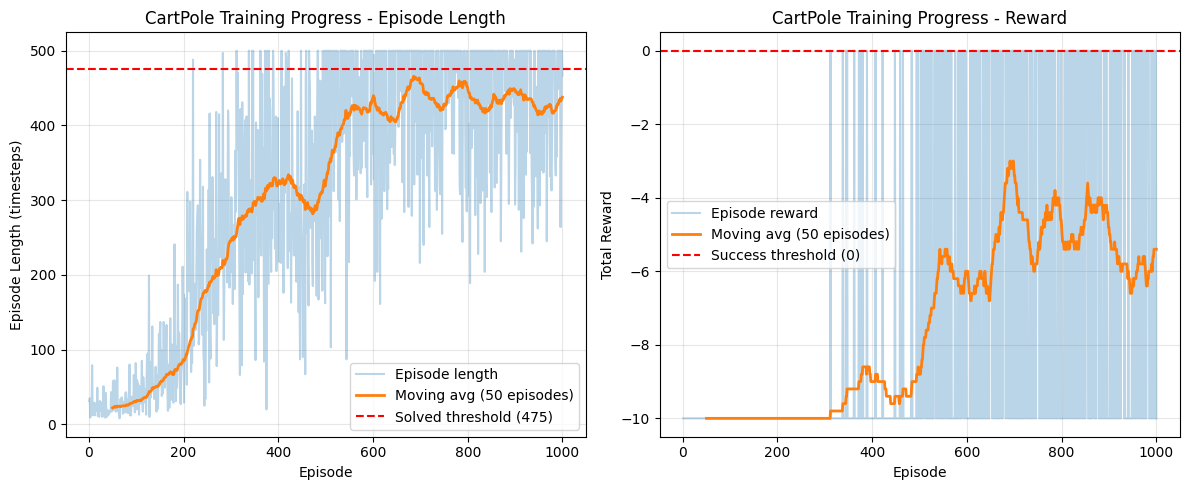


Final 100 episodes:
  Average length: 427.1 timesteps
  Average reward: -5.9
  Not yet solved (threshold: 475)


In [9]:
# 7. Plot training curves

episodes = np.arange(1, len(episode_lengths) + 1)

# Calculate moving average (window=50)
window = 50
moving_avg = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')

# Plot episode lengths
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(episodes, episode_lengths, alpha=0.3, label='Episode length')
plt.plot(episodes[window-1:], moving_avg, linewidth=2, label=f'Moving avg ({window} episodes)')
plt.axhline(y=475, color='r', linestyle='--', label='Solved threshold (475)')
plt.xlabel('Episode')
plt.ylabel('Episode Length (timesteps)')
plt.title('CartPole Training Progress - Episode Length')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot rewards
plt.subplot(1, 2, 2)
plt.plot(episodes, episode_rewards, alpha=0.3, label='Episode reward')
moving_avg_reward = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.plot(episodes[window-1:], moving_avg_reward, linewidth=2, label=f'Moving avg ({window} episodes)')
plt.axhline(y=0, color='r', linestyle='--', label='Success threshold (0)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('CartPole Training Progress - Reward')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
final_avg_length = np.mean(episode_lengths[-100:])
final_avg_reward = np.mean(episode_rewards[-100:])
print(f"\nFinal 100 episodes:")
print(f"  Average length: {final_avg_length:.1f} timesteps")
print(f"  Average reward: {final_avg_reward:.1f}")
if final_avg_length >= 475:
    print(f"  Task SOLVED! (threshold: 475)")
else:
    print(f"  Not yet solved (threshold: 475)")

## 8. Testing the Trained Agent

This section evaluates the trained agent without learning to assess its true performance.

### Testing vs Training

**During testing:**
- Learning is **disabled** (`learn=False` in step)
- Agent uses only its learned policy
- No exploration (deterministic behavior)
- Reward is not used for updates

This shows the agent's true capability without the noise of exploration and learning.

In [10]:
# 8. Test the trained agent

def test_agent(num_test_episodes=10):
    """Evaluate the trained agent without learning."""
    
    test_lengths = []
    test_rewards = []
    
    print(f"\nTesting agent for {num_test_episodes} episodes (no learning)...\n")
    
    for episode in range(num_test_episodes):
        obs, _ = env.reset()
        total_reward = 0.0
        
        for t in range(max_timesteps):
            csdr = encode_observation(obs)
            h.step([csdr, h.get_prediction_cis(1)], False, 0.0)
            action = h.get_prediction_cis(1)[0]
            obs, reward, term, trunc, _ = env.step(action)
            total_reward += reward
            
            if term or trunc:
                break
        
        test_lengths.append(t + 1)
        test_rewards.append(total_reward)
        print(f"Test episode {episode + 1}: {t + 1} timesteps, reward = {total_reward:.1f}")
    
    avg_length = np.mean(test_lengths)
    avg_reward = np.mean(test_rewards)
    
    print(f"\nTest results over {num_test_episodes} episodes:")
    print(f"  Average length: {avg_length:.1f} timesteps")
    print(f"  Average reward: {avg_reward:.1f}")
    print(f"  Best episode:   {max(test_lengths)} timesteps")
    print(f"  Worst episode:  {min(test_lengths)} timesteps")
    
    return test_lengths, test_rewards

# Run evaluation
test_lengths, test_rewards = test_agent(num_test_episodes=10)


Testing agent for 10 episodes (no learning)...

Test episode 1: 379 timesteps, reward = 379.0
Test episode 2: 405 timesteps, reward = 405.0
Test episode 3: 500 timesteps, reward = 500.0
Test episode 4: 440 timesteps, reward = 440.0
Test episode 5: 500 timesteps, reward = 500.0
Test episode 6: 485 timesteps, reward = 485.0
Test episode 7: 500 timesteps, reward = 500.0
Test episode 8: 500 timesteps, reward = 500.0
Test episode 9: 305 timesteps, reward = 305.0
Test episode 10: 500 timesteps, reward = 500.0

Test results over 10 episodes:
  Average length: 451.4 timesteps
  Average reward: 451.4
  Best episode:   500 timesteps
  Worst episode:  305 timesteps




### Next Steps

**Potential experiments:**
1. Modify `encoding_scale` (0.5 to 10.0) to observe how sensitivity affects learning
2. Change `input_resolution` (16, 64, 128) to compare granularity vs. memory
3. Try different reward shaping strategies
4. Add a third hierarchy layer to test if deeper memory improves performance
5. Apply this approach to other environments (MountainCar, Acrobot, LunarLander)

> **Learn more:** See [EnvRunner Implementation](./env_runner_implementation.md) for the simpler high-level approach.

In [ ]:
# 10. Cleanup

env.close()
print("Environment closed.")
print("\nTo save the trained model:")
print("  h.save_to_file('cartpole_manual.ohr')")
print("\nTo load it later:")
print("  h = neo.Hierarchy(file_name='cartpole_manual.ohr')")